## Load the data

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# data_path = "trimerge19sep26.xlsx"
data_path = "trimerge19sep26_jamie.csv"
df = pd.read_csv(data_path)

## Flatten the data

In [23]:
def flatten_columns(df):
    cols = [c.strip().lower().replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "").replace("%", "pct") for c in df.columns]
    df.columns = cols
    return df

df = flatten_columns(df)

## Explore the data

In [24]:
df[["run", "time", "28_18_ratio", "spectral_temperature", "spectral_temperature_error", "fit_r_squared"]].head(10)

,run,time,28_18_ratio,spectral_temperature,spectral_temperature_error,fit_r_squared
0,1,2:48:00 PM,2.52,94.721651,6.705200,0.528553
1,2,5:04:00 PM,2.52,74.355098,2.563813,0.821307
2,3,5:13:25 PM,0.10,79.365842,13.469327,0.236639
3,4,5:26:02 PM,0.19,72.301470,11.882992,0.235769
4,5,5:39:06 PM,0.49,71.245055,7.659719,0.370486
5,6,5:53:33 PM,0.74,61.154093,6.721287,0.365034
6,7,6:08:25 PM,0.98,73.954075,7.102272,0.389423
7,8,6:21:00 PM,1.95,70.783289,5.568778,0.475797
8,9,6:32:21 PM,4.95,72.631344,7.149309,0.386250
9,10,6:45:44 PM,12.10,76.667196,8.699975,0.338145


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 76 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   date                             66 non-null     object 
 1   time                             66 non-null     object 
 2   detector                         1 non-null      object 
 3   comments                         9 non-null      object 
 4   action                           2 non-null      object 
 5   run                              66 non-null     int64  
 6   csd                              64 non-null     object 
 7   inj_a                            66 non-null     float64
 8   extr_a                           66 non-null     float64
 9   cent_a                           66 non-null     float64
 10  sext_a                           66 non-null     int64  
 11  inj_t                            66 non-null     float64
 12  extr_t                  

In [26]:
# summarise the key columns
df[["total_power", "28_18_ratio", "spectral_temperature", "fit_r_squared", "fast_count"]].describe()

,total_power,28_18_ratio,spectral_temperature,fit_r_squared,fast_count
count,66.000000,66.000000,66.000000,66.000000,66.000000
mean,2566.045455,5.710758,74.232474,0.659814,21188.015152
std,1862.612214,6.344373,5.878893,0.172299,16431.993384
min,637.000000,0.100000,61.097467,0.235769,4032.000000
25%,1161.750000,0.740000,70.810762,0.548321,9909.000000
50%,1858.000000,2.675000,74.067390,0.663300,14456.500000
75%,3586.250000,7.995000,76.621329,0.810462,29124.500000
max,6834.000000,20.030000,94.721651,0.901651,62215.000000


In [27]:
# check which columns are sparsely filled (percentage of total rows that are filled)
fill = df.count() / len(df)
fill[fill < 1.0]

detector           0.015152
comments           0.136364
action             0.030303
csd                0.969697
xenon_pct          0.000000
csd_name           0.969697
peak_energy_kev    0.000000
dtype: float64

## Plot the data

number of points kept: 64


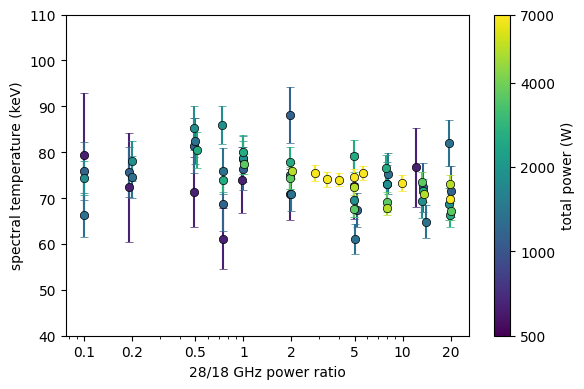

In [28]:
def plot_te_vs_ratio(df):
    "Plot spectral temperature against the 28/18 GHz power ratio, coloured by total power"
    power = df["comments"].ffill().str.extract(r"(\d+) W")[0].astype(float)# total power set for each block
    keep = power.notna() # skip the tune up runs, which have no power block
    print(f"number of points kept: {keep.sum()}")
    norm = LogNorm(500, 7000)# map total power onto the colormap, log spaced across the labelled range
    cmap = plt.get_cmap("viridis")# vivid hue sweep, so neighbouring power blocks stay distinct
    plt.figure(figsize=(6, 4))
    for p in sorted(power[keep].unique()):
        g = df[keep & (power == p)].sort_values("28_18_ratio")# join the sweep in ratio order
        plt.errorbar(g["28_18_ratio"], g["spectral_temperature"], yerr=g["spectral_temperature_error"], marker="o", markersize=6, linestyle="", linewidth=1.5, capsize=3, alpha=1.0, markeredgecolor="black", markeredgewidth=0.5, color=cmap(norm(p)))
    plt.xscale("log")
    plt.xticks([0.1, 0.2, 0.5, 1, 2, 5, 10, 20], labels=["0.1", "0.2", "0.5", "1", "2", "5", "10", "20"])# write the doubings out in full rather than as powers of ten
    plt.xlabel("28/18 GHz power ratio")
    plt.ylabel("spectral temperature (keV)")
    plt.ylim(40,110)
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=plt.gca(), label="total power (W)")
    cbar.set_ticks([500, 1000, 2000, 4000, 7000], labels=["500", "1000", "2000", "4000", "7000"])# doublings written out in full
    cbar.minorticks_off()# drop the labelled log minor ticks
    plt.tight_layout()
    plt.savefig("spectralTemperature_vs_powerRatio_vs_totalPower.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_te_vs_ratio(df)

number of power blocks: 8


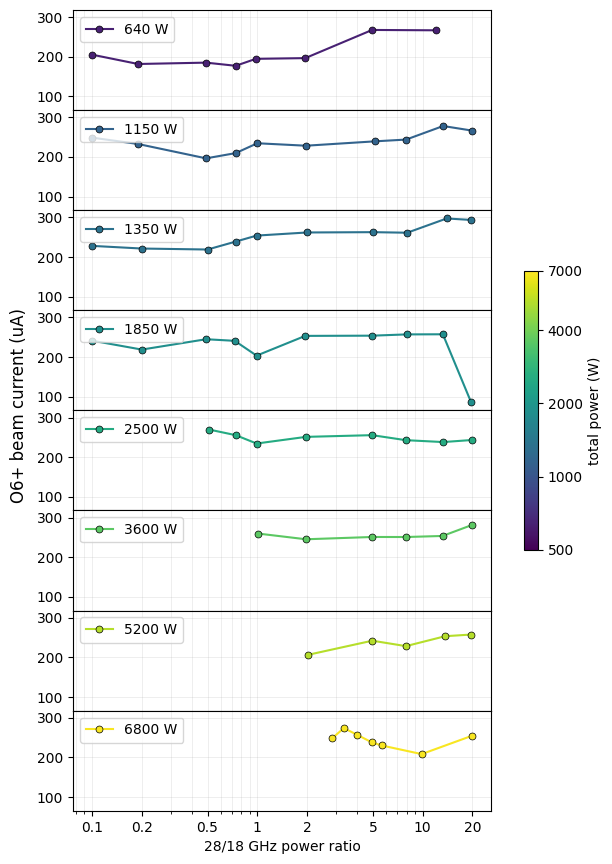

In [34]:
def plot_o6_vs_ratio(df):
    "Plot O6+ beam current against the 28/18 GHz power ratio, one panel per total power"
    power = df["comments"].ffill().str.extract(r"(\d+) W")[0].astype(float)# total power set for each block
    keep = power.notna() #& (df["total_power"] > 1e3)# skip the tune up runs, and the lowest block
    blocks = sorted(power[keep].unique())
    print(f"number of power blocks: {len(blocks)}")
    y = df["o6+_beam_current"]# beam current in microamps
    norm = LogNorm(500, 7000)# same mapping as the spectral temperature plot
    cmap = plt.get_cmap("viridis")
    fig, axes = plt.subplots(len(blocks), 1, figsize=(6, 1.3 * len(blocks)), sharex=True, sharey=True, gridspec_kw={"hspace": 0})# panels stacked with no gap
    for ax, p in zip(axes, blocks):
        g = df[keep & (power == p)].sort_values("28_18_ratio")# join the sweep in ratio order
        ax.plot(g["28_18_ratio"], y[g.index], marker="o", markersize=5, linestyle="-", linewidth=1.5, markeredgecolor="black", markeredgewidth=0.5, color=cmap(norm(p)), label=f"{p:.0f} W")
        ax.legend(frameon=True, loc="upper left")# same corner in every panel
        ax.grid(True, which="both", linewidth=0.5, alpha=0.3)# grid on the major and minor log lines
    ypad = 0.1 * (y[keep].max() - y[keep].min())# a little headroom above and below the data
    axes[0].set_ylim(y[keep].min() - ypad, y[keep].max() + ypad)# one set of limits, shared by every panel
    axes[-1].set_xscale("log")
    axes[-1].set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10, 20], labels=["0.1", "0.2", "0.5", "1", "2", "5", "10", "20"])# write the doublings out in full
    axes[-1].set_xlabel("28/18 GHz power ratio")
    fig.supylabel("O6+ beam current (uA)")# a single label for the whole column
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, fraction=0.03, pad=0.07, label="total power (W)")# thin strip on the right
    cbar.set_ticks([500, 1000, 2000, 4000, 7000], labels=["500", "1000", "2000", "4000", "7000"])# doublings written out in full
    cbar.minorticks_off()# drop the labelled log minor ticks
    plt.show()

plot_o6_vs_ratio(df)

this 

number of power blocks: 8


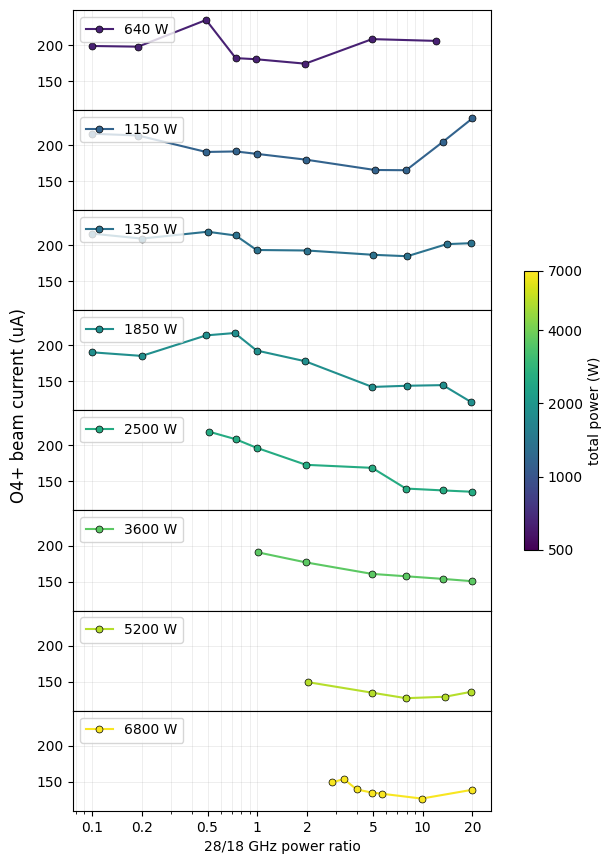

In [36]:
def plot_o4_vs_ratio(df):
    "Plot O4+ beam current against the 28/18 GHz power ratio, one panel per total power"
    power = df["comments"].ffill().str.extract(r"(\d+) W")[0].astype(float)# total power set for each block
    keep = power.notna() #& (df["total_power"] > 1e3)# skip the tune up runs, and the lowest block
    blocks = sorted(power[keep].unique())
    print(f"number of power blocks: {len(blocks)}")
    y = df["o4+_beam_current"]# beam current in microamps
    norm = LogNorm(500, 7000)# same mapping as the spectral temperature plot
    cmap = plt.get_cmap("viridis")
    fig, axes = plt.subplots(len(blocks), 1, figsize=(6, 1.3 * len(blocks)), sharex=True, sharey=True, gridspec_kw={"hspace": 0})# panels stacked with no gap
    for ax, p in zip(axes, blocks):
        g = df[keep & (power == p)].sort_values("28_18_ratio")# join the sweep in ratio order
        ax.plot(g["28_18_ratio"], y[g.index], marker="o", markersize=5, linestyle="-", linewidth=1.5, markeredgecolor="black", markeredgewidth=0.5, color=cmap(norm(p)), label=f"{p:.0f} W")
        ax.legend(frameon=True, loc="upper left")# same corner in every panel
        ax.grid(True, which="both", linewidth=0.5, alpha=0.3)# grid on the major and minor log lines
    ypad = 0.1 * (y[keep].max() - y[keep].min())# a little headroom above and below the data
    axes[0].set_ylim(y[keep].min() - ypad, y[keep].max() + ypad)# one set of limits, shared by every panel
    axes[-1].set_xscale("log")
    axes[-1].set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10, 20], labels=["0.1", "0.2", "0.5", "1", "2", "5", "10", "20"])# write the doublings out in full
    axes[-1].set_xlabel("28/18 GHz power ratio")
    fig.supylabel("O4+ beam current (uA)")# a single label for the whole column
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, fraction=0.03, pad=0.07, label="total power (W)")# thin strip on the right
    cbar.set_ticks([500, 1000, 2000, 4000, 7000], labels=["500", "1000", "2000", "4000", "7000"])# doublings written out in full
    cbar.minorticks_off()# drop the labelled log minor ticks
    plt.show()

plot_o4_vs_ratio(df)

number of power blocks: 8


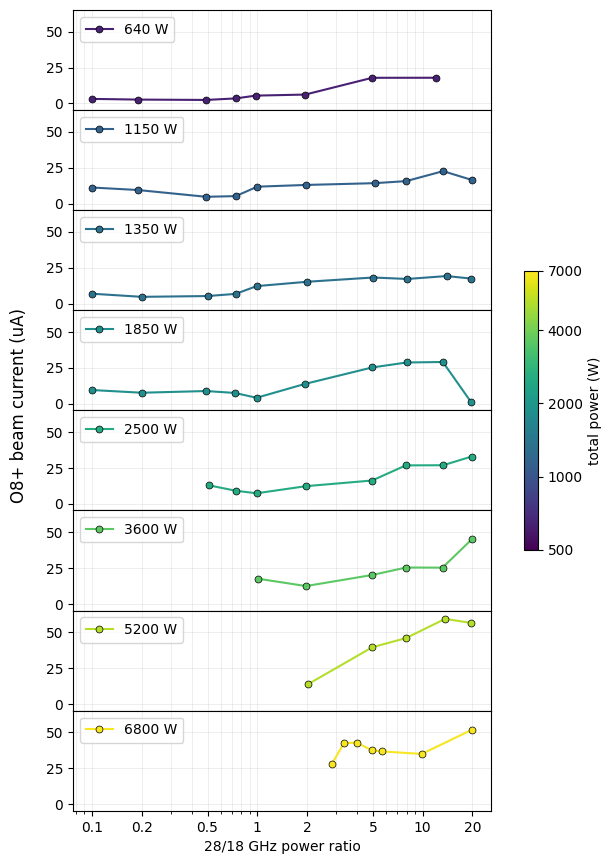

In [37]:
def plot_o8_vs_ratio(df):
    "Plot O8+ beam current against the 28/18 GHz power ratio, one panel per total power"
    power = df["comments"].ffill().str.extract(r"(\d+) W")[0].astype(float)# total power set for each block
    keep = power.notna() #& (df["total_power"] > 1e3)# skip the tune up runs, and the lowest block
    blocks = sorted(power[keep].unique())
    print(f"number of power blocks: {len(blocks)}")
    y = df["o8+_beam_current"]# beam current in microamps
    norm = LogNorm(500, 7000)# same mapping as the spectral temperature plot
    cmap = plt.get_cmap("viridis")
    fig, axes = plt.subplots(len(blocks), 1, figsize=(6, 1.3 * len(blocks)), sharex=True, sharey=True, gridspec_kw={"hspace": 0})# panels stacked with no gap
    for ax, p in zip(axes, blocks):
        g = df[keep & (power == p)].sort_values("28_18_ratio")# join the sweep in ratio order
        ax.plot(g["28_18_ratio"], y[g.index], marker="o", markersize=5, linestyle="-", linewidth=1.5, markeredgecolor="black", markeredgewidth=0.5, color=cmap(norm(p)), label=f"{p:.0f} W")
        ax.legend(frameon=True, loc="upper left")# same corner in every panel
        ax.grid(True, which="both", linewidth=0.5, alpha=0.3)# grid on the major and minor log lines
    ypad = 0.1 * (y[keep].max() - y[keep].min())# a little headroom above and below the data
    axes[0].set_ylim(y[keep].min() - ypad, y[keep].max() + ypad)# one set of limits, shared by every panel
    axes[-1].set_xscale("log")
    axes[-1].set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10, 20], labels=["0.1", "0.2", "0.5", "1", "2", "5", "10", "20"])# write the doublings out in full
    axes[-1].set_xlabel("28/18 GHz power ratio")
    fig.supylabel("O8+ beam current (uA)")# a single label for the whole column
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, fraction=0.03, pad=0.07, label="total power (W)")# thin strip on the right
    cbar.set_ticks([500, 1000, 2000, 4000, 7000], labels=["500", "1000", "2000", "4000", "7000"])# doublings written out in full
    cbar.minorticks_off()# drop the labelled log minor ticks
    plt.show()

plot_o8_vs_ratio(df)

number of power blocks: 8


C:\Users\intwa\AppData\Local\Temp\ipykernel_2928\1007580830.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


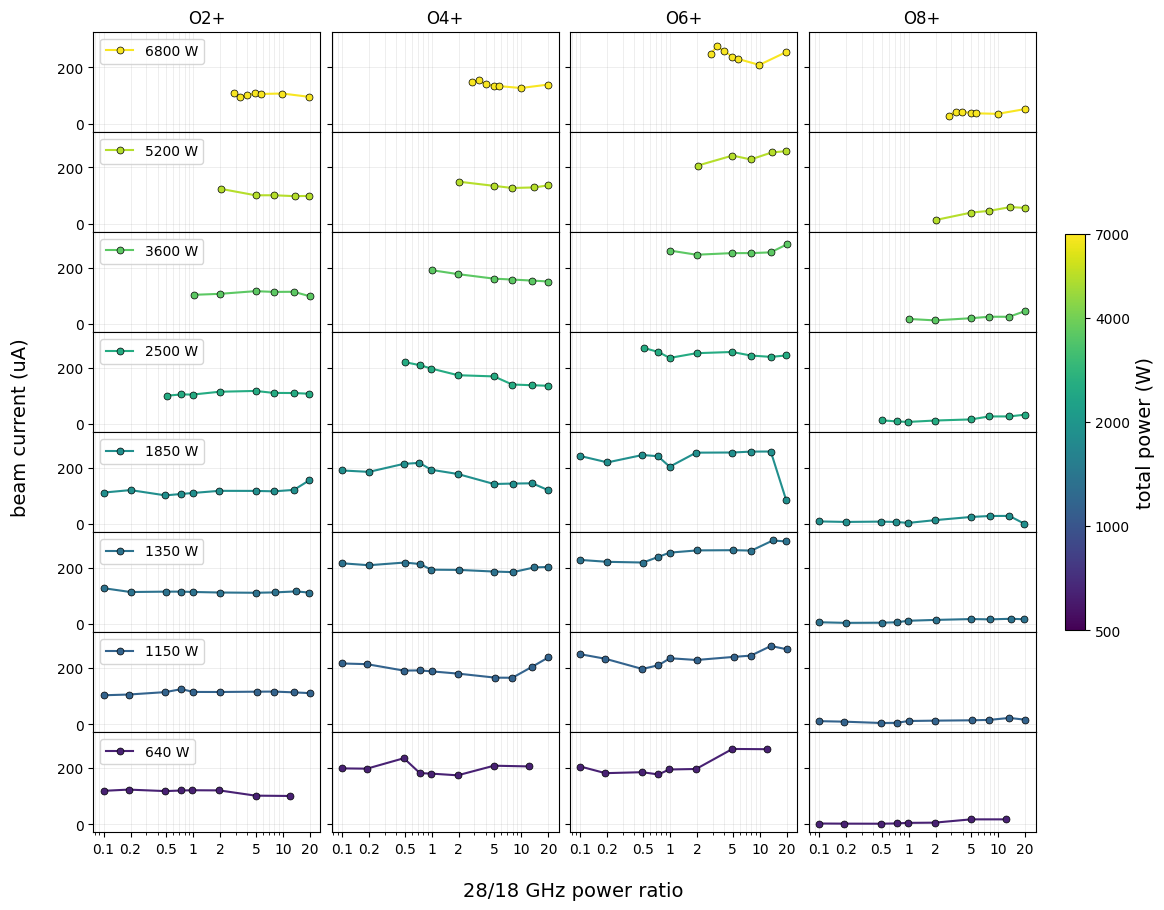

In [41]:
def plot_charge_states_vs_ratio(df):
    "Plot O2+, O4+, O6+ and O8+ beam currents against the 28/18 GHz power ratio, one column per charge state"
    power = df["comments"].ffill().str.extract(r"(\d+) W")[0].astype(float)# total power set for each block
    keep = power.notna()# skip the tune up runs, which have no power block
    blocks = sorted(power[keep].unique())
    print(f"number of power blocks: {len(blocks)}")
    states = ["o2+", "o4+", "o6+", "o8+"]# one column per charge state
    norm = LogNorm(500, 7000)# same mapping as the spectral temperature plot
    cmap = plt.get_cmap("viridis")
    fig, axes = plt.subplots(len(blocks), len(states), figsize=(3.2 * len(states), 1.3 * len(blocks)), sharex=True, sharey=True, gridspec_kw={"hspace": 0, "wspace": 0.05})# rows touch, columns get a little room for the tick labels
    yall = df.loc[keep, [s + "_beam_current" for s in states]].values# all plotted currents in microamps
    ypad = 0.1 * (yall.max() - yall.min())# a little headroom above and below the data
    for j, s in enumerate(states):
        y = df[s + "_beam_current"]# beam current in microamps
        axes[0, j].set_title(f"O{s[1]}+")# one column header per charge state
        for i, p in enumerate(reversed(blocks)):# highest total power at the top of the plot
            ax = axes[i, j]
            g = df[keep & (power == p)].sort_values("28_18_ratio")# join the sweep in ratio order
            ax.plot(g["28_18_ratio"], y[g.index], marker="o", markersize=5, linestyle="-", linewidth=1.5, markeredgecolor="black", markeredgewidth=0.5, color=cmap(norm(p)), label=f"{p:.0f} W" if j == 0 else None)
            ax.grid(True, which="both", linewidth=0.5, alpha=0.3)# grid on the major and minor log lines
            if j == 0:
                ax.legend(frameon=True, loc="upper left")# label each row once, in the first column
    axes[0, 0].set_ylim(yall.min() - ypad, yall.max() + ypad)# one set of limits, shared by every panel
    for j in range(len(states)):
        axes[-1, j].set_xscale("log")
        axes[-1, j].set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10, 20], labels=["0.1", "0.2", "0.5", "1", "2", "5", "10", "20"])# write the doublings out in full
    fig.supxlabel("28/18 GHz power ratio", x=0.5, y=0.045, fontsize=14)# a single label for the whole grid, sitting close under the bottom row
    fig.supylabel("beam current (uA)", x=0.06, fontsize=14)# a single label for the whole grid, sitting close to the left column
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, fraction=0.02, pad=0.03,label="total power (W)")# thin strip on the right
    cbar.ax.yaxis.label.set_size(14)# larger colourbar label
    cbar.set_ticks([500, 1000, 2000, 4000, 7000], labels=["500", "1000", "2000", "4000", "7000"])# doublings written out in full
    cbar.minorticks_off()# drop the labelled log minor ticks
    plt.tight_layout()
    plt.savefig("beamCurrent_vs_powerRatio_vs_totalPower.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_charge_states_vs_ratio(df)


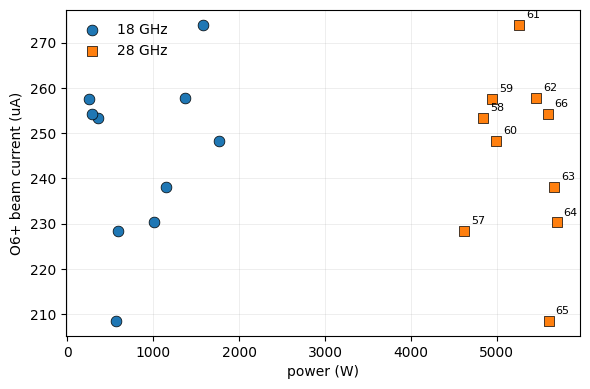

In [43]:
def plot_o6_power_last_runs(df, n=10):
    "Plot O6+ beam current of the last n runs against the actual 18 and 28 GHz powers"
    last = df.tail(n).copy()# most recent runs at the bottom of the log
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(last["18_ghz"], last["o6+_beam_current"], marker="o", s=60, color="tab:blue", edgecolor="black", linewidth=0.5, label="18 GHz", zorder=3)
    ax.scatter(last["28_ghz"], last["o6+_beam_current"], marker="s", s=60, color="tab:orange", edgecolor="black", linewidth=0.5, label="28 GHz", zorder=3)
    ax.set_xlabel("power (W)")
    ax.set_ylabel("O6+ beam current (uA)")
    ax.legend(frameon=False)
    ax.grid(True, which="both", linewidth=0.5, alpha=0.3)
    for i, row in last.iterrows():
        ax.annotate(f"{int(row['run'])}", (row["28_ghz"], row["o6+_beam_current"]), textcoords="offset points", xytext=(5, 5), fontsize=8)
    plt.tight_layout()
    plt.show()

plot_o6_power_last_runs(df, n=10)